In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

os.makedirs("../figures", exist_ok=True)
sns.set_theme(style="whitegrid")

titanic = pd.read_csv("../data/titanic_propre.csv")

taxis = sns.load_dataset("taxis")
taxis["pickup"] = pd.to_datetime(taxis["pickup"])
taxis["dropoff"] = pd.to_datetime(taxis["dropoff"])
taxis["duree_minutes"] = (taxis["dropoff"] - taxis["pickup"]).dt.total_seconds() / 60
taxis = taxis[(taxis["duree_minutes"] > 0) & (taxis["duree_minutes"] <= 180)]
taxis

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,duree_minutes
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,6.250000
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,7.083333
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,7.400000
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,25.866667
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,9.533333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan,3.566667
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx,56.383333
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn,19.116667
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn,5.066667


**Type : histogramme.** Il montre comment une variable numérique (l'âge) se répartit en tranches.

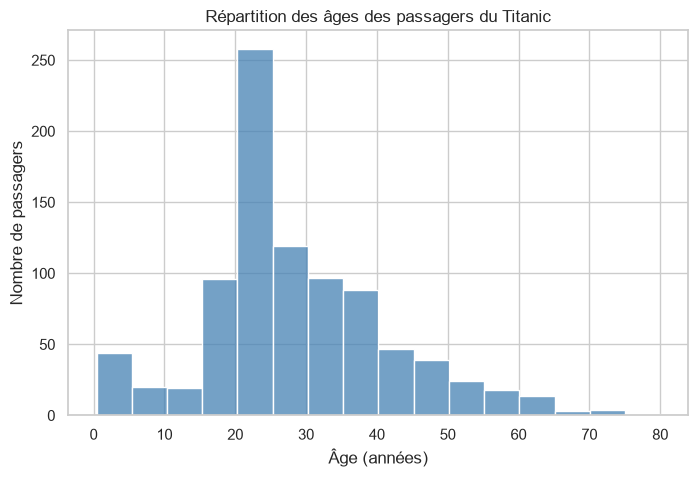

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=titanic, x="age", bins=16, color="steelblue", ax=ax)
ax.set_title("Répartition des âges des passagers du Titanic")
ax.set_xlabel("Âge (années)")
ax.set_ylabel("Nombre de passagers")
fig.savefig("../figures/graphique_1_age.png", dpi=150, bbox_inches="tight")
plt.show()

**Conclusion 1 :** Les passagers sont surtout jeunes : l'âge médian est de 26 ans et environ 65 % ont entre 20 et 40 ans. Le pic autour de 25 ans est en partie dû aux âges manquants remplacés par la médiane à l'exercice 08.

**Type : barres groupées.** Elles comparent une valeur (le taux de survie) entre catégories : trois classes, deux sexes.

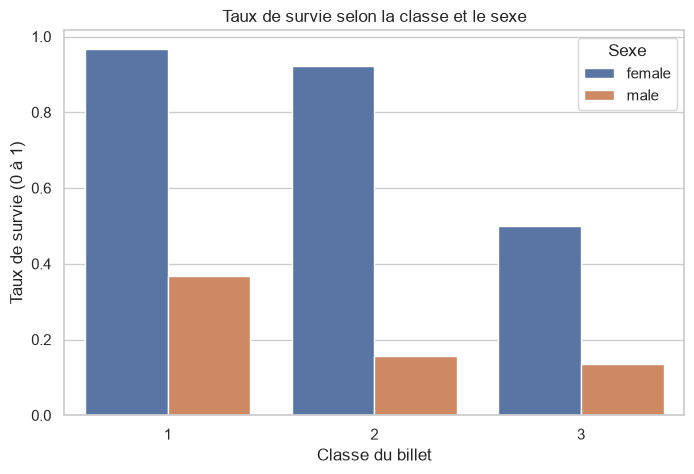

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=titanic, x="pclass", y="survived", hue="sex", errorbar=None, ax=ax)
ax.set_title("Taux de survie selon la classe et le sexe")
ax.set_xlabel("Classe du billet")
ax.set_ylabel("Taux de survie (0 à 1)")
ax.legend(title="Sexe")
fig.savefig("../figures/graphique_2_survie.png", dpi=150, bbox_inches="tight")
plt.show()

**Conclusion 2 :** Dans chaque classe, les femmes survivent beaucoup mieux que les hommes (96.8 % contre 36.9 % en 1re classe, 50.0 % contre 13.5 % en 3e). La classe compte aussi : en 3e classe, les femmes survivent à peine plus que les femmes... en 1re classe les hommes.

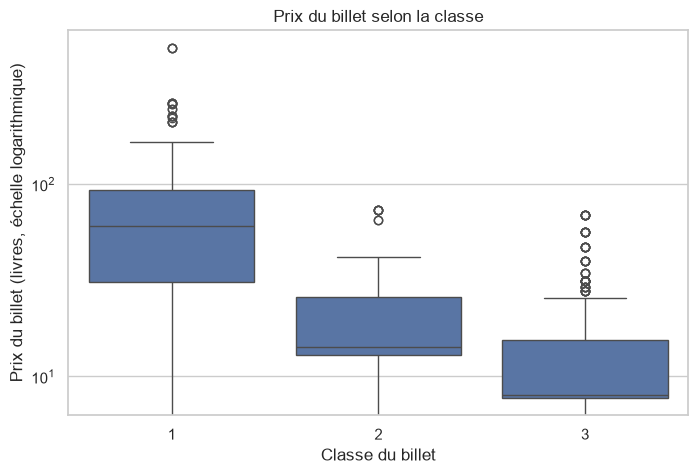

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=titanic, x="pclass", y="fare", ax=ax)
ax.set_yscale("log")
ax.set_title("Prix du billet selon la classe")
ax.set_xlabel("Classe du billet")
ax.set_ylabel("Prix du billet (livres, échelle logarithmique)")
fig.savefig("../figures/graphique_3_prix.png", dpi=150, bbox_inches="tight")
plt.show()

**Conclusion 3 :** Le prix médian passe de 8.0 en 3e classe à 14.2 en 2e et 60.3 en 1re. La 1re classe est aussi la plus dispersée, avec des billets allant jusqu'à 512.33.

**Type : courbe.** Elle convient à une évolution dans le temps, jour après jour.

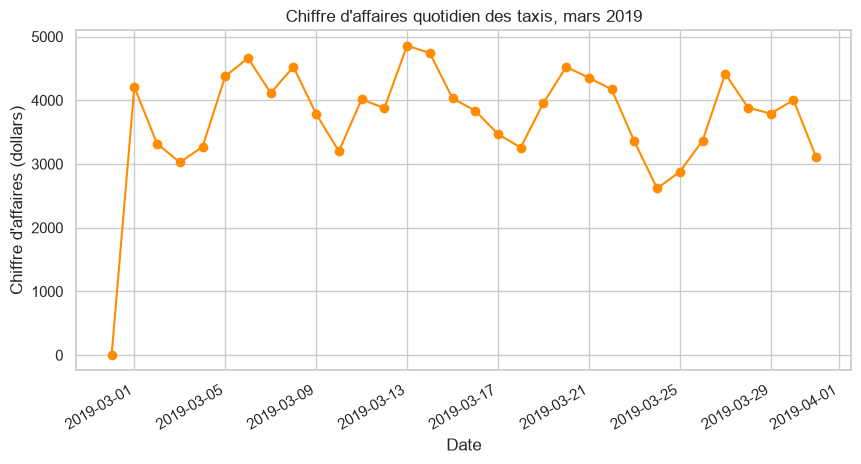

In [5]:
taxis["jour"] = pd.to_datetime(taxis["pickup"].dt.date)
ca_par_jour = taxis.groupby("jour")["total"].sum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ca_par_jour.index, ca_par_jour.values, marker="o", color="darkorange")
ax.set_title("Chiffre d'affaires quotidien des taxis, mars 2019")
ax.set_xlabel("Date")
ax.set_ylabel("Chiffre d'affaires (dollars)")
fig.autofmt_xdate()
fig.savefig("../figures/graphique_4_ca_taxis.png", dpi=150, bbox_inches="tight")
plt.show()

**Conclusion 4 :** Le chiffre d'affaires oscille entre environ 2 600 et 4 900 dollars par jour (record le 13 mars, minimum le 24 mars). Il baisse régulièrement le week-end, par exemple les 9-10, 16-17 et 23-24 mars. Le 28 février n'est pas significatif : il ne compte qu'une course.

**Type : nuage de points.** Il montre la relation entre deux variables numériques, une course par point. La transparence évite que les points se cachent entre eux.

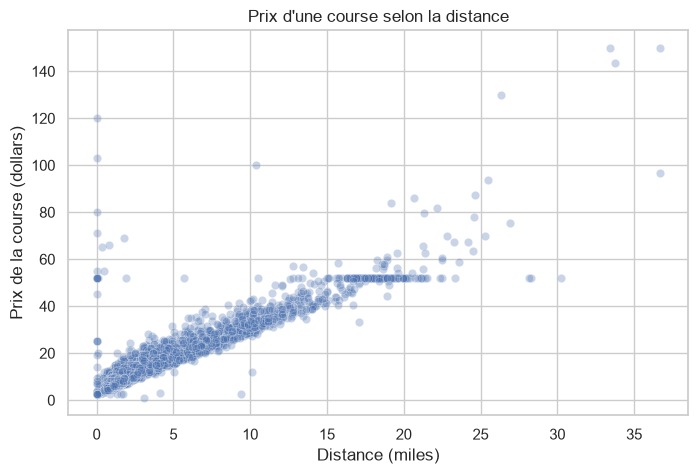

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=taxis, x="distance", y="fare", alpha=0.3, ax=ax)
ax.set_title("Prix d'une course selon la distance")
ax.set_xlabel("Distance (miles)")
ax.set_ylabel("Prix de la course (dollars)")
fig.savefig("../figures/graphique_5_distance_prix.png", dpi=150, bbox_inches="tight")
plt.show()

**Conclusion 5 :** Le prix augmente presque en ligne droite avec la distance : la corrélation est de 0.92, et une course coûte environ 4.67 dollars de départ plus 2.78 dollars par mile. Quelques points s'écartent de la ligne (attente dans les embouteillages, courses à prix fixe).